# PCA 개요
* 주성분 분석(PCA(Principal Component Analysis))
* 가장 대표적 차원 축소 기법
* 컴퓨터 비전에서, 특히 얼굴 인식에서 Eigen-face라 하는 PCA 변환이 잘 사용. 원본 얼굴 이미지 변환해 사용
* 여러 변수 간에 존재하는 상관관계를 이용, 이를 대표한느 주성분(principal component)를 추출해 차원을 축소함
* 원본 데이터의 피처 개수에 비해 매우 작은 주성분으로 원본 데이터의 총 변동성을 대부분 설명할 수 있는 분석법
* 기존 데이터의 정보 유실이 최소화되는 것이 당연 -> 가장 높은 분산을 가지는 데이터 축을 찾아 이 축으로 차원 축소 -> PCA의 주성분으로 삼음
  * 분산이 데이터 특성을 가장 잘 나타내는 것으로 간주
* 예시 : 키-몸무게를 각 축으로 가진 데이터셋이 있다 하자
  * 데이터 변동성이 가장 큰 방향으로 축 생성
  * -> 새로운 축으로 데이터 투영
  * -> 새로운 축을 기준으로 데이터 표현
  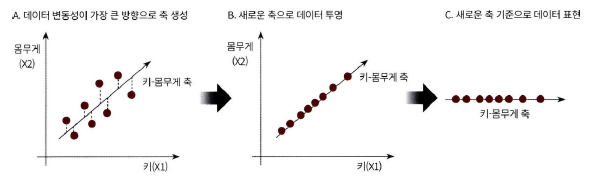
* 순서
  * 가장 큰 데이터 변동성(variance)를 기반으로, 첫 번째 데이터 벡터 축 생성함
  * 두 번째 축은 첫 번째 벡터 축에 직각이 되는 벡터(직표벡터)를 축으로 함
  * 세 번째 축은 두 번째 축과 직각이 되는 벡터를 설정
  * 벡터 축에 원본 데이터를 투영하면, 벡터 축의 개수만큼 차원으로 원본 데이터가 차원 축소됨
  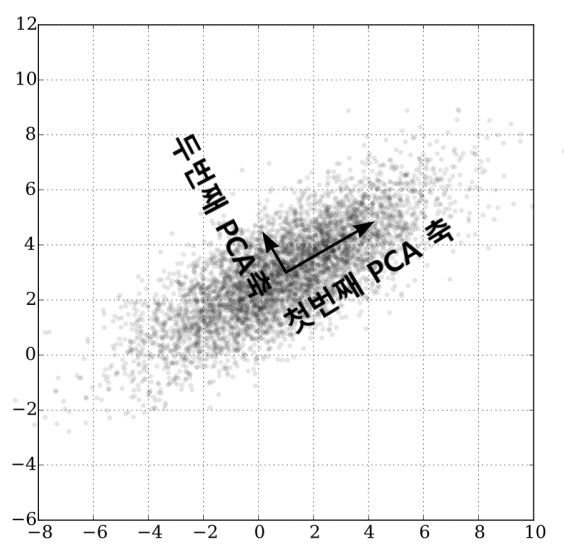

# 선형대수 관점에서의 PCA
* 입력 데이터의 공분산 행렬(covariance matrix)을 고윳값 분해하고, 이 고유벡터에 입력 데이터를 선형변환하는 것
  * 이 때 고유벡터가 PCA의 주성분 벡터임. 입력 데이터의 분산이 큰 방향
  * 고윳값(eigenvalue) : 이 고유벡터의 크기이자, 입력 데이터의 분산
* 선형 변환
  * 특정 벡터에 행렬을 곱해 새로운 벡터로 변환하는 것
  * 특정 벡터를 하나의 공간에서 다른 공간으로 투영하는 개념으로도 볼 수 있음 -> 이 행렬을 공간으로 가정
* 공분산
  * 분산 : 한 개의 특정한 변수의 데이터 변동
  * 공분산 : 두 변수간의 변동
    * 사람 키 변수 X, 몸무게 변수 Y일 때, 공분산 Cov(X, Y) > 0 는, X가 증가할 때 Y도 증가함을 의미
  * 공분산 행렬 : 여러 변수와 관련된 공분산을 포함하는 정방형 행렬
    * 대각선 원소는 각 변수(X, Y, Z)의 분산 의미 -> X의 분산이 3.0
    * 그 외 원소는 가능한 모든 변수 쌍 간의 공분산 의미 -> X와 Y의 공분산이 -0.71
  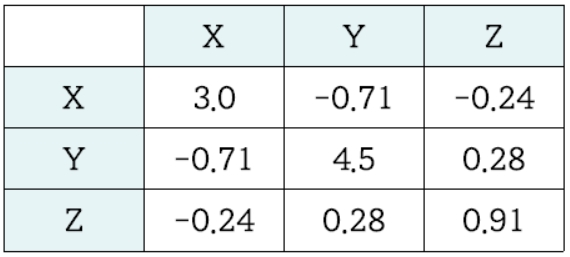
* 고유벡터
  * 어떤 행렬을 곱하더라도 방향이 변하지 않고 그 크기만 변하는 벡터
  * 여러 개가 존재할 수 있음
  * 행렬이 작용하는 힘의 방향과 관계 있음 -> 행렬 분해하는 데 사용됨
  * 정방 행렬 : 최대 그 차원으 수만큼 고유 벡터 가질 수 있음 -> 3X3 행렬은 3개의 고유 벡터 가질 수 있는 것.
* 공분산 행렬
  * 정방행렬(Diagonal Matrix, 열과 행이 같은 행렬)이자, 대칭행렬(Symmetric Matrix, 정방행렬 중 대각원소를 중심으로 원소 값이 대칭되는 행렬, A.T = A)
  * 개별 분산값을 대각원소로 하는 대칭행렬임
  * 대칭행렬이므로 고윳값 분해에 유용 -> 고유 벡터를 직교행렬(orthogonal matrix)로 & 고유값을 정방 행렬로 대각화 가능
  * 입력 데이터의 공분산 행렬을 C라 하면 아래 식으로 분해 가능.(P = nxn의 직교 행렬, Σ는 nXn 정방행렬, P.T는 P행렬의 전치 행렬) -> 아래 식은 고유 벡터 행렬과 고유값 행렬인 아래아래 그림으로 대응됨
  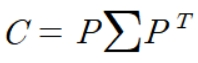
  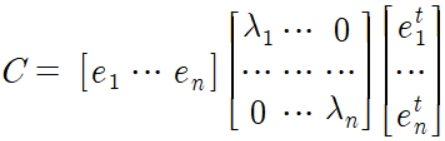
  * 공분산 C = 고유 벡터 직교 행렬 * 고유값 정방 행렬 * 고유벡터의 직교행렬의 전치행렬
  * ei = i번째 고유 벡터, λi=i번째 고유 벡터의 크기, e1=가장 분산이 큰 방향을 가진 고유벡터, e2=e1에 수직이면서 다음으로 분산이 큰 방향을 가진 고유벡터

# PCA의 핵심
* 입력 데이터의 공분산 행렬이 고유벡터와 고윳값으로 분해될 수 있음
* PCA = 이렇게 분해된 고유 벡터를 이용해 입력 데이터를 선형변환하는 방식
* PCA의 순서
  1. 입력 데이터셋의 공분산 행렬을 생성
  2. 공분산 행렬의 고유벡터와 고유값을 계산
  3. 고유값이 가장 큰 순으로 K개(PCA의 변환 차수)만큼 고유벡터를 추출
  4. 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터를 변환

# 붓꽃 데이터셋을 PCA로 차원 축소
* 4개의 속성을 2개의 차원으로 압축해보자

In [22]:
### 라이브러리 임포트

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
### 데이터 로드 및 변환

iris = load_iris()
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns=columns)
irisDF['target'] = iris.target
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


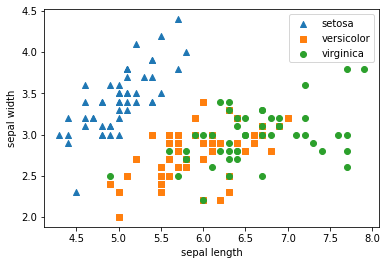

In [4]:
### 품종에 따른 데이터 분포 2차원 시각화 - sepal

markers = ['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF[iris['target']==i]['sepal_length']
    y_axis_data = irisDF[iris['target']==i]['sepal_width']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

* versicolor, virginia는 sepal width, length만으로는 분류가 어려움
* PCA로 4개 -> 2개 압축하자
* 그렇게 하기 전에, 개별 속성을 함께 스케일링 해야 함
  * PCA는 여러 속성의 값을 연산해야 함 -> 속성의 스케일에 영향 받음 -> PCA 압축 전 각 속성값을 동일한 스케일로 변환해야 함
  * StandardScaler 이용해 표준 정규 분포로 변환

In [6]:
###스케일 변환
iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

In [9]:
###PCA 변환

pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled) #PCA 데이터셋을 넘파이 행렬로 가짐
print(iris_pca.shape)

pca_columns=['pca_comp_1', 'pca_comp_2']
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head(3)

(150, 2)


,pca_comp_1,pca_comp_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


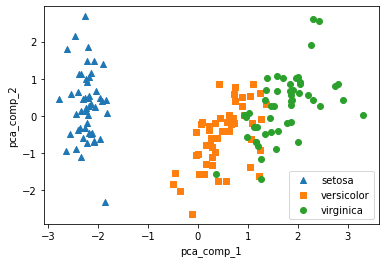

In [10]:
### 2개 속성으로 변환된 데이터셋을 시각화

markers = ['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[iris['target']==i]['pca_comp_1']
    y_axis_data = irisDF_pca[iris['target']==i]['pca_comp_2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('pca_comp_1')
plt.ylabel('pca_comp_2')
plt.show()

* 위 결과로, 이전엔 잘 구분 안되었던 것이 비교적 잘 구분됨 -> comp_1이 원본 데이터의 변동성을 잘 반영하고 있음
* PCA 컴포넌트 별로 원본 데이터의 변동성을 얼마나 반영하고 있느지 확인 : PCA 객체의 explained_variance_ratio_ 속성 --> 전체 변동성에서 개별 PCA 컴포넌트별로 차지하는 변동성 비율 제공

In [11]:
### PCA 컴포넌트 별로 원본 데이터의 변동성을 얼마나 반영하나?

print(pca.explained_variance_ratio_) #[0.72962445 0.22850762]이므로, 두 개의 요소만으로도 원본 데이터의 95프로 설명 가능

[0.72962445 0.22850762]


In [16]:
### 원본 데이터셋과 변환된 데이터셋에 각각 분류 적용해 결과 비교

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, iris.data, iris.target, scoring='accuracy', cv=3)
print('원본 데이터 교차 검증 개별 정확도 : ', scores)
print('원본 데이터 평균 정확도 : ', np.mean(scores))

pca_x = irisDF_pca[['pca_comp_1', 'pca_comp_2']]
scores_pca = cross_val_score(rcf, pca_x, iris.target, scoring='accuracy', cv=3)
print('PCA 변환 데이터 교차 검증 개별 정확도 : ', scores_pca)
print('PCA 변환 데이터 평균 정확도 : ', np.mean(scores_pca))

원본 데이터 교차 검증 개별 정확도 :  [0.98 0.94 0.96]
원본 데이터 평균 정확도 :  0.96
PCA 변환 데이터 교차 검증 개별 정확도 :  [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도 :  0.88


# 신용카드 고객 데이터세트
* 더 많은 피처 가진 데이터셋을 변환하고 영향도 비교해보자
* defalt payment next month 속성이 타겟값으로, 다음달 연체 여부임. 연체=1, 정상납부=0
* 23개의 속성 데이터셋이 있으나, 각 속성끼리 상관도가 높음

In [18]:
### 데이터 로딩 및 변환

df = pd.read_excel('../credit_card_clients/credit_card.xls', header=1, sheet_name='Data').iloc[0:, 1:]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [21]:
### DF 가공

df.rename(columns={'PAY_0': 'PAY_1', 'default payment next month':'default'}, inplace=True) #칼럼명 변경
y_target = df['default']
x_features = df.drop('default', axis=1)

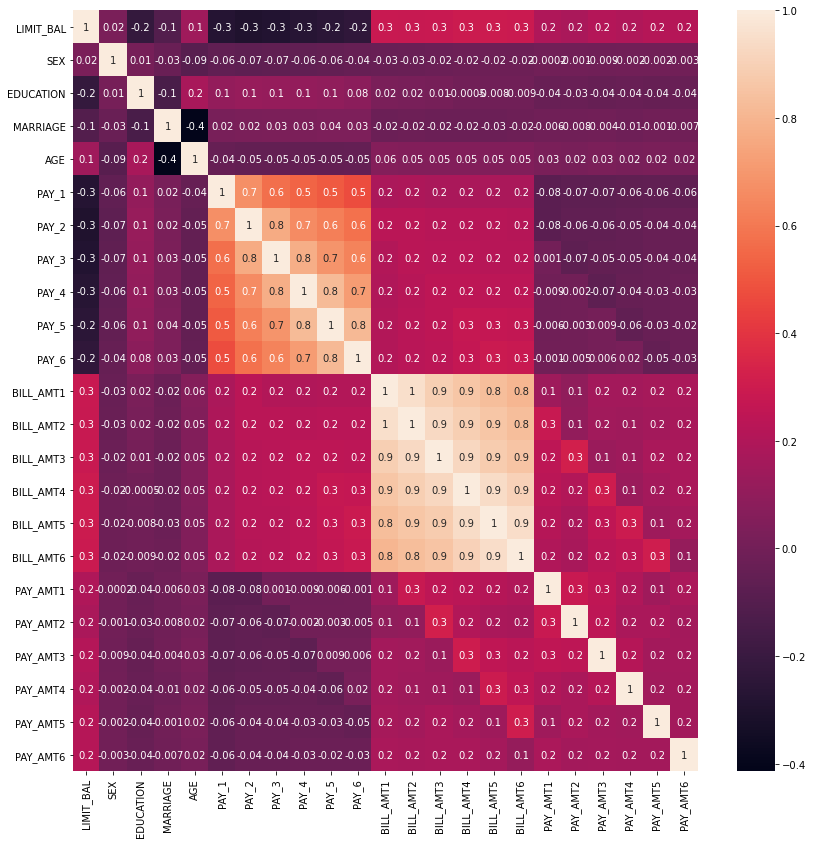

In [23]:
### 각 속성 간의 상관도 구하고 시각화

corr = x_features.corr()
plt.figure(figsize=(14, 14))
sns.heatmap(corr, annot=True, fmt='.1g')

In [28]:
### BILL_AMT_1~6이 상관도 높으므로 이 6개를 2개의 컴포넌트로 PCA 변환하고 개별 컴포넌트의 변동성을 확인

cols_bill = ['BILL_AMT' + str(i) for i in range(1, 7)]
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(x_features[cols_bill])
pca = PCA(n_components=2)
pca.fit(df_cols_scaled)
print('PCA componets 별 변동성 : ', pca.explained_variance_ratio_)

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, x_features, y_target, scoring='accuracy', cv=3)
print('cv=3인 경우의 개별 폴드 세트별 정확도 : ', scores)
print('평균 정확도 : {0:.4f}'.format(np.mean(scores)))

scaler = StandardScaler()
df_scaled = scaler.fit_transform(x_features)
pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf, df_pca, y_target, scoring='accuracy', cv=3)
print('cv=3인 경우의 PCA 변환된 개별 폴드 세트별 정확도 : ', scores_pca)
print('PCA 변환 데이터 세트 평균 정확도 : {0:.4f}'.format(np.mean(scores_pca)))

PCA componets 별 변동성 :  [0.90555253 0.0509867 ]
cv=3인 경우의 개별 폴드 세트별 정확도 :  [0.8072 0.82   0.8225]
평균 정확도 : 0.8166
cv=3인 경우의 PCA 변환된 개별 폴드 세트별 정확도 :  [0.7911 0.7949 0.7997]
PCA 변환 데이터 세트 평균 정확도 : 0.7952
